Font in use: Times New Roman
Saved: /Users/nandan/Desktop/CTCs/IBM/threepanel_abc.png
Saved: /Users/nandan/Desktop/CTCs/IBM/threepanel_abc.pdf


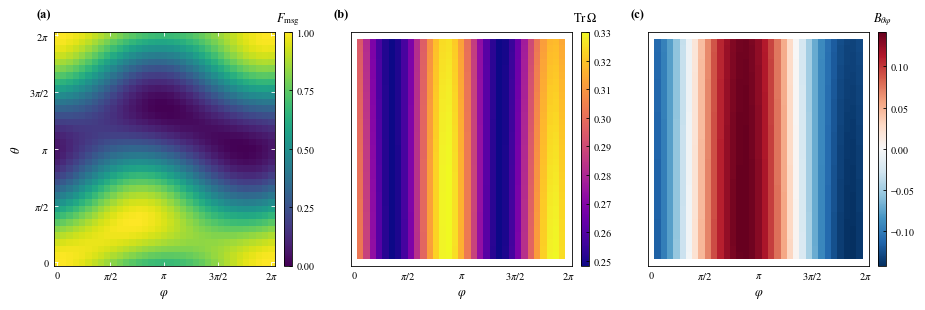

In [2]:
"""
PRX 3-panel heatmap figure: F_msg, Tr Omega, B_thetaphi.

Tweakables grouped at the top.  Run:
    python threepanel_abc.py

Outputs:
    threepanel_abc.png  (600 dpi)
    threepanel_abc.pdf  (vector, for LaTeX)

------------------------------------------------------------------
FONT NOTES (project standard)
------------------------------------------------------------------
Tries to use real Times New Roman if available on your system; if
not, falls back to STIX Two Text (a Times look-alike that ships
with matplotlib).  Either way, the output looks like Times — no
DejaVu Serif silent fallback.

If you want to force real Times New Roman:
  - macOS / Windows: usually already installed; should be detected.
  - Linux: `sudo apt install msttcorefonts-installer ttf-mscorefonts-installer`
           then `rm -rf ~/.cache/matplotlib` to clear the font cache.

------------------------------------------------------------------
INPUT
------------------------------------------------------------------
This script expects the precomputed grid data in INPUT_NPZ, with
keys: thetas, phis, F_grid, trO, Btp.  Each grid array has shape
(n_theta, n_phi).
"""
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
from matplotlib.ticker import FixedLocator, FuncFormatter

# ============================================================
# Tweakable parameters
# ============================================================
INPUT_NPZ   = "panel_abc_e.npz"
OUT_BASE    = "/Users/nandan/Desktop/CTCs/IBM/threepanel_abc"

# Bigger panels (was 7.2 x 2.7).  Width unchanged so it still fits a
# double-column slot; height bumped so panels are taller and squarer.
FIGSIZE_IN  = (9.0, 3.2)

# Colormaps
CMAP_F   = "viridis"      # F_msg ∈ [0, 1]
CMAP_TRO = "plasma"       # Tr Ω (sequential, non-negative)
CMAP_B   = "RdBu_r"       # B_θφ (diverging, ±)

# ============================================================
# Font selection
# ============================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman"]
elif "Times" in installed:
    SERIF_STACK = ["Times"]
else:
    SERIF_STACK = ["STIX Two Text", "STIXGeneral", "DejaVu Serif"]

# ============================================================
# PRX rcParams
# ============================================================
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          SERIF_STACK,
    "mathtext.fontset":    "stix",
    "font.size":           8,
    "axes.labelsize":      9,
    "axes.titlesize":      9,
    "xtick.labelsize":     7.5,
    "ytick.labelsize":     7.5,
    "axes.linewidth":      0.6,
    "xtick.major.width":   0.6,
    "ytick.major.width":   0.6,
    "xtick.major.size":    2.8,
    "ytick.major.size":    2.8,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# ============================================================
# Load data
# ============================================================
d = np.load(INPUT_NPZ)
thetas = d["thetas"]
phis   = d["phis"]
F      = d["F_grid"]
trO    = d["trO"]
Btp    = d["Btp"]

# ============================================================
# Helpers
# ============================================================
def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    step = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = (c[:-1] + c[1:]) / 2
    e[0]    = c[0]  - step[0]  / 2
    e[-1]   = c[-1] + step[-1] / 2
    return e

def pi_fmt(val, _pos):
    if np.isclose(val, 0):          return "0"
    if np.isclose(val, np.pi/2):    return r"$\pi/2$"
    if np.isclose(val, np.pi):      return r"$\pi$"
    if np.isclose(val, 3*np.pi/2):  return r"$3\pi/2$"
    if np.isclose(val, 2*np.pi):    return r"$2\pi$"
    return ""

phi_e   = edges_from_centers(phis)
theta_e = edges_from_centers(thetas)
PI_TICKS = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]

# ============================================================
# Figure layout
# ============================================================
# 3 (heatmap, colorbar) pairs, each followed by a wider spacer
# so the colorbar title ("F_msg", etc.) has breathing room before
# the next panel's y-axis.
fig = plt.figure(figsize=FIGSIZE_IN)
gs = fig.add_gridspec(
    nrows=1, ncols=8,
    width_ratios=[1.0, 0.035, 0.18,    # panel a | cbar | spacer
                  1.0, 0.035, 0.18,    # panel b | cbar | spacer
                  1.0, 0.035],         # panel c | cbar
    wspace=0.10,
    left=0.06, right=0.985, top=0.88, bottom=0.15,
)
ax_a  = fig.add_subplot(gs[0, 0]); cax_a = fig.add_subplot(gs[0, 1])
ax_b  = fig.add_subplot(gs[0, 3], sharey=ax_a); cax_b = fig.add_subplot(gs[0, 4])
ax_c  = fig.add_subplot(gs[0, 6], sharey=ax_a); cax_c = fig.add_subplot(gs[0, 7])

# ============================================================
# Draw heatmaps
# ============================================================
def draw(ax, data, cmap, vmin, vmax, ylabel=False, yticks=False):
    im = ax.pcolormesh(phi_e, theta_e, data, cmap=cmap,
                       vmin=vmin, vmax=vmax,
                       shading="auto", rasterized=True)
    ax.set_xlim(phi_e[0], phi_e[-1])
    ax.set_ylim(theta_e[0], theta_e[-1])
    ax.xaxis.set_major_locator(FixedLocator(PI_TICKS))
    ax.yaxis.set_major_locator(FixedLocator(PI_TICKS))
    ax.xaxis.set_major_formatter(FuncFormatter(pi_fmt))
    ax.yaxis.set_major_formatter(FuncFormatter(pi_fmt))
    ax.set_xlabel(r"$\varphi$")
    ax.tick_params(which="both", color="white", top=True, right=True)
    for s in ax.spines.values():
        s.set_color("black"); s.set_linewidth(0.6)
    if ylabel: ax.set_ylabel(r"$\theta$")
    if not yticks: plt.setp(ax.get_yticklabels(), visible=False)
    return im

B_max = float(np.nanmax(np.abs(Btp)))

im_a = draw(ax_a, F,   CMAP_F,   0.0, 1.0,                          ylabel=True, yticks=True)
im_b = draw(ax_b, trO, CMAP_TRO, float(np.nanmin(trO)), float(np.nanmax(trO)))
im_c = draw(ax_c, Btp, CMAP_B,   -B_max, B_max)

# ============================================================
# Colorbars — labels placed as titles above each bar, with extra
# vertical padding so they don't crowd the top tick label.
# ============================================================
CB_LABEL_PAD = 8       # ← bump this if the title still feels too close

def style_cb(cb, label, ticks=None):
    cb.ax.set_title(label, fontsize=9, pad=CB_LABEL_PAD)
    if ticks is not None:
        cb.set_ticks(ticks)
    cb.ax.tick_params(width=0.6, length=2.5, direction="in", labelsize=7.5)
    cb.outline.set_linewidth(0.6)

cb_a = fig.colorbar(im_a, cax=cax_a)
style_cb(cb_a, r"$F_{\mathrm{msg}}$", [0, 0.25, 0.5, 0.75, 1.0])
cb_b = fig.colorbar(im_b, cax=cax_b)
style_cb(cb_b, r"$\mathrm{Tr}\,\Omega$")
cb_c = fig.colorbar(im_c, cax=cax_c)
style_cb(cb_c, r"$B_{\theta\varphi}$")

# ============================================================
# Panel letters
# ============================================================
for ax, txt in [(ax_a, "(a)"), (ax_b, "(b)"), (ax_c, "(c)")]:
    ax.text(-0.08, 1.05, txt, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=9, fontweight="bold")

# ============================================================
# Save
# ============================================================
fig.savefig(f"{OUT_BASE}.png", dpi=600, bbox_inches="tight")
fig.savefig(f"{OUT_BASE}.pdf",            bbox_inches="tight")
print("Font in use:", mpl.rcParams["font.serif"][0])
print(f"Saved: {OUT_BASE}.png")
print(f"Saved: {OUT_BASE}.pdf")

In [5]:
"""
Section V.C — Updated panel figure
==================================

Changes from previous version:
  1. Three-panel horizontal layout: (a) F_msg, (b) Tr Ω, (c) B_θφ.
     The p_succ panel has been removed.
  2. Times New Roman font throughout. No per-panel titles.
  3. Tr Ω colorbar shows odd-2nd-decimal ticks: 0.25, 0.27, 0.29, 0.31, 0.33.
  4. QGT panels (b, c) now fill the full (θ,φ) grid — boundary rows/columns
     are computed with one-sided finite differences instead of being left
     as NaN, so there are no white margins.
"""

import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator
from math import pi

from qiskit import QuantumRegister, QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity

OUT   = '/Users/nandan/Desktop/CTCs/IBM'
SEED  = 42
RNG   = np.random.default_rng(SEED)

THETA_MSG_FIXED  = 2.5349076035276403
VARPHI_MSG_FIXED = 2.0022404587009195

# =============================================================================
#  CIRCUIT BUILDERS  (unchanged)
# =============================================================================
def _decoder_core(qc, C, E, R, A, M, G, Y,
                  theta_msg, varphi_msg,
                  theta_rx, phi_rz, generator='Rx'):
    qc.u(theta_msg, varphi_msg, 0.0, M[0])
    qc.swap(C[0], M[0]); qc.barrier()
    qc.h(E[0]); qc.cx(E[0], M[0])
    qc.h(R[0]); qc.cx(R[0], G[0])
    qc.h(A[0]); qc.cx(A[0], Y[0]); qc.barrier()

    qc.rz(phi_rz, C[0])
    if generator == 'Rx':
        qc.rx(theta_rx, C[0])
    else:
        qc.ry(theta_rx, C[0])

    qc.cz(C[0],R[0]); qc.cz(E[0],R[0]); qc.cz(C[0],E[0])
    qc.h(C[0]); qc.h(E[0]); qc.h(R[0])
    qc.cz(C[0],R[0]); qc.cz(C[0],E[0]); qc.cz(E[0],R[0]); qc.barrier()

    qc.cz(A[0],G[0]); qc.cz(M[0],A[0]); qc.cz(G[0],M[0])
    qc.h(A[0]); qc.h(M[0]); qc.h(G[0])
    qc.cz(A[0],G[0]); qc.cz(G[0],M[0]); qc.cz(M[0],A[0]); qc.barrier()

    qc.rz(pi,R[0]); qc.rx(pi,R[0]); qc.rx(pi,G[0])
    qc.swap(R[0],G[0]); qc.rz(pi,R[0]); qc.barrier()

    qc.cz(A[0],G[0]); qc.cz(M[0],A[0]); qc.cz(G[0],M[0])
    qc.h(A[0]); qc.h(M[0]); qc.h(G[0])
    qc.cz(A[0],G[0]); qc.cz(G[0],M[0]); qc.cz(M[0],A[0]); qc.barrier()

    qc.rz(pi,A[0]); qc.rx(pi,A[0]); qc.rx(pi,Y[0])
    qc.swap(A[0],Y[0]); qc.rz(pi,A[0]); qc.barrier()

    qc.cz(A[0],G[0]); qc.cz(M[0],A[0]); qc.cz(G[0],M[0])
    qc.h(A[0]); qc.h(M[0]); qc.h(G[0])
    qc.cz(A[0],G[0]); qc.cz(G[0],M[0]); qc.cz(M[0],A[0]); qc.barrier()

    qc.rz(pi,R[0]); qc.rx(pi,R[0]); qc.rx(pi,G[0])
    qc.swap(R[0],G[0]); qc.rz(pi,R[0]); qc.barrier()

    qc.cx(R[0],G[0]); qc.h(R[0])


def build_circuit(theta_rx, phi_rz, theta_msg, varphi_msg, generator='Rx'):
    C=QuantumRegister(1,'C'); E=QuantumRegister(1,'E'); R=QuantumRegister(1,'R')
    A=QuantumRegister(1,'A'); M=QuantumRegister(1,'M'); G=QuantumRegister(1,'G')
    Y=QuantumRegister(1,'Y')
    qc=QuantumCircuit(C,E,R,G,M,A,Y)
    _decoder_core(qc,C,E,R,A,M,G,Y,theta_msg,varphi_msg,theta_rx,phi_rz,generator)
    return qc


# =============================================================================
#  GRID PRECOMPUTATION
# =============================================================================
def compute_grid(thetas, phis, theta_msg, varphi_msg, generator='Rx', verbose=True):
    N_th, N_ph = len(thetas), len(phis)
    psi_grid = np.zeros((N_th, N_ph, 128), dtype=complex)
    F_grid   = np.zeros((N_th, N_ph))

    qcm = QuantumCircuit(1)
    qcm.u(theta_msg, varphi_msg, 0.0, 0)
    psi_msg = Statevector.from_instruction(qcm)

    for i, th in enumerate(thetas):
        if verbose and i % 10 == 0:
            print(f"    row {i+1}/{N_th}", end='\r')
        for j, ph in enumerate(phis):
            psi = Statevector.from_instruction(
                      build_circuit(th, ph, theta_msg, varphi_msg, generator)
                  ).data
            psi /= np.linalg.norm(psi)
            psi_grid[i, j] = psi

            rho_f = psi[:, None] * psi.conj()[None, :]
            rho_Y = partial_trace(rho_f, [0, 1, 2, 3, 4, 5])
            F_grid[i, j] = float(state_fidelity(rho_Y, psi_msg))
    if verbose:
        print()
    return psi_grid, F_grid


# =============================================================================
#  GAUGE-INVARIANT QGT  (boundary rows/cols now use one-sided differences)
# =============================================================================
def phase_align_1d(arr):
    out = arr.copy()
    for k in range(1, len(arr)):
        ov = np.vdot(out[k-1], out[k])
        if abs(ov) > 1e-12:
            out[k] *= np.exp(-1j * np.angle(ov))
    return out


def compute_qgt(psi_grid, thetas, phis, gauge_fix=True):
    """
    Full-grid QGT: interior points use central differences, boundary points
    use forward/backward one-sided differences so no NaN edges remain.
    """
    N_th, N_ph = len(thetas), len(phis)
    dth = thetas[1] - thetas[0]
    dph = phis[1]   - phis[0]

    if gauge_fix:
        pa = psi_grid.copy()
        for i in range(N_th): pa[i] = phase_align_1d(pa[i])
        for j in range(N_ph): pa[:, j] = phase_align_1d(pa[:, j])
    else:
        pa = psi_grid

    # np.gradient handles boundaries with one-sided differences automatically.
    dpsi_dth = np.gradient(pa, dth, axis=0)
    dpsi_dph = np.gradient(pa, dph, axis=1)

    Ott = np.zeros((N_th, N_ph))
    Opp = np.zeros((N_th, N_ph))
    Btp = np.zeros((N_th, N_ph))

    for i in range(N_th):
        for j in range(N_ph):
            psi = pa[i, j]
            dt  = dpsi_dth[i, j]
            dp  = dpsi_dph[i, j]
            ip  = lambda a, b: np.vdot(a, b)

            Qtt = ip(dt, dt) - ip(dt, psi) * np.conj(ip(dt, psi))
            Qpp = ip(dp, dp) - ip(dp, psi) * np.conj(ip(dp, psi))
            Qtp = ip(dt, dp) - ip(dt, psi) * np.conj(ip(dp, psi))

            Ott[i, j] = float(Qtt.real)
            Opp[i, j] = float(Qpp.real)
            Btp[i, j] = float(Qtp.imag)

    trace_O = Ott + Opp
    return Ott, Opp, Btp, trace_O


# =============================================================================
#  AXIS HELPERS — multiples of π
# =============================================================================
def _pi_label(x, _pos):
    if np.isclose(x, 0.0, atol=1e-9):
        return '0'
    n = x / np.pi
    if np.isclose(n, round(n), atol=1e-6):
        k = int(round(n))
        if k == 1:    return r'$\pi$'
        if k == -1:   return r'$-\pi$'
        return rf'${k}\pi$'
    if np.isclose(2*n, round(2*n), atol=1e-6):
        num = int(round(2*n))
        if num == 1:  return r'$\pi/2$'
        if num == -1: return r'$-\pi/2$'
        if num % 2 == 0:
            k = num // 2
            return rf'${k}\pi$'
        return rf'${num}\pi/2$'
    return rf'${n:.2f}\pi$'

PI_FORMATTER = FuncFormatter(_pi_label)
PI_TICKS = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]


def apply_pi_axes(ax):
    ax.xaxis.set_major_locator(FixedLocator(PI_TICKS))
    ax.yaxis.set_major_locator(FixedLocator(PI_TICKS))
    ax.xaxis.set_major_formatter(PI_FORMATTER)
    ax.yaxis.set_major_formatter(PI_FORMATTER)


# =============================================================================
#  MAIN
# =============================================================================
N      = 100
thetas = np.linspace(0, 2*pi, N)
phis   = np.linspace(0, 2*pi, N)

print("[1/1] Grid: Rz·Rx, fixed message ...")
pg_A, Fg_A = compute_grid(thetas, phis,
                           THETA_MSG_FIXED, VARPHI_MSG_FIXED,
                           generator='Rx')
Ott_A, Opp_A, Btp_A, trO_A = compute_qgt(pg_A, thetas, phis, gauge_fix=True)


# =============================================================================
#  FIGURE — three horizontal panels, Times New Roman, no titles
# =============================================================================
print("\nGenerating figure ...")

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',     # serif math to match Times
    'font.size': 12,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 180,
    'pdf.fonttype': 42,
})

extent = [phis[0], phis[-1], thetas[0], thetas[-1]]


def heatmap(ax, data, panel_label, cbar_label,
            cmap='viridis', vmin=None, vmax=None, cbar_ticks=None):
    """Plot a (θ,φ) heatmap with a bold (x) panel tag and a labelled colorbar."""
    im = ax.imshow(data, origin='lower', extent=extent, aspect='auto',
                   cmap=cmap, vmin=vmin, vmax=vmax, interpolation='bilinear')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)
        cbar.set_ticklabels([f'{t:.2f}' for t in cbar_ticks])
    # Colorbar label placed above the bar (like the screenshot)
    cbar.ax.set_title(cbar_label, fontsize=13, pad=8)
    ax.set_xlabel(r'$\phi$', fontsize=13)
    ax.set_ylabel(r'$\theta$', fontsize=13)
    apply_pi_axes(ax)
    # Bold panel label in upper-left, outside the plot box
    ax.text(-0.18, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='bottom', ha='left')


fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) F_msg
heatmap(axes[0], Fg_A, '(a)', r'$F_{\mathrm{msg}}$')

# (b) Tr Ω with odd-2nd-decimal ticks
trO_ticks = [0.25, 0.27, 0.29, 0.31, 0.33]
heatmap(axes[1], trO_A, '(b)', r'$\mathrm{Tr}\,\Omega$',
        cmap='plasma',
        vmin=trO_ticks[0], vmax=trO_ticks[-1],
        cbar_ticks=trO_ticks)

# (c) B_θφ — symmetric colormap around 0
b_max = np.nanmax(np.abs(Btp_A))
heatmap(axes[2], Btp_A, '(c)', r'$B_{\theta\varphi}$',
        cmap='RdBu_r', vmin=-b_max, vmax=b_max)

fig.tight_layout()
fig.savefig(OUT + 'threefigpanelV.pdf', bbox_inches='tight', dpi=600)
plt.close(fig)
print("  [✓] threefigpanelVC.pdf")

[1/1] Grid: Rz·Rx, fixed message ...
    row 91/100

Generating figure ...
  [✓] threefigpanelVC.pdf


In [6]:
"""
Hardware QGT Proxy - combined three-panel figure
================================================
Input:  qgt_echo_results.json
Output: fig_qgt_echo_combined_matched.pdf
        fig_qgt_echo_combined_matched.png

Panels:
  (a) Echo survival probability P_00(delta)
  (b) Per-delta estimator of g_{theta theta}
  (c) g_{phi phi}(theta) scan

Matched to the three-panel Section V.C figure style:
  - 16 x 4.6 inch horizontal layout
  - Times New Roman serif stack, STIX math
  - font.size=12, axes.labelsize=13, tick labels=11
  - bold 15 pt panel labels at (-0.18, 1.05)
  - no titles, no grids
  - inward ticks, top/right ticks enabled
  - embedded TrueType fonts in PDF
"""

import json
import math
import os
from pathlib import Path

import numpy as np
import matplotlib as mpl
mpl.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, FixedLocator, MultipleLocator

# =============================================================================
#  PATHS
# =============================================================================
# This keeps the script usable both on your Mac and inside this ChatGPT sandbox.
LOCAL_JSON = Path("/Users/nandan/Desktop/CTCs/IBM/qgt_echo_results.json")
if LOCAL_JSON.exists():
    ECHO_JSON = LOCAL_JSON
    OUT_DIR = LOCAL_JSON.parent
else:
    ECHO_JSON = Path(__file__).resolve().with_name("qgt_echo_results.json")
    OUT_DIR = Path(__file__).resolve().parent

OUT_STEM = "fig_qgt_echo_combined_matched"

# =============================================================================
#  FONT / STYLE - matched to the reference three-panel figure
# =============================================================================
installed = {f.name for f in fm.fontManager.ttflist}
if "Times New Roman" in installed:
    SERIF_STACK = ["Times New Roman", "Times", "DejaVu Serif"]
elif "Times" in installed:
    SERIF_STACK = ["Times", "Times New Roman", "DejaVu Serif"]
else:
    SERIF_STACK = ["Times New Roman", "Times", "STIX Two Text", "STIXGeneral", "DejaVu Serif"]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": SERIF_STACK,
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.grid": False,
})

# Project palette, preserved from earlier echo/QGT figures.
C_HW   = "#C0392B"   # hardware:   red
C_SIM  = "#2980B9"   # simulator:  blue
C_ANAL = "#27AE60"   # analytical: green
C_FIT  = "#8E44AD"   # HW fit:     purple

# =============================================================================
#  HELPERS
# =============================================================================
def pi_fmt(val, _pos):
    n = val / math.pi
    if abs(n) < 0.01:
        return "0"
    if abs(n - 0.25) < 0.01:
        return r"$\pi/4$"
    if abs(n - 0.5) < 0.01:
        return r"$\pi/2$"
    if abs(n - 0.75) < 0.01:
        return r"$3\pi/4$"
    if abs(n - 1.0) < 0.01:
        return r"$\pi$"
    return rf"${n:.2f}\pi$"


def panel_label(ax, label):
    """Panel label matched to the reference figure."""
    ax.text(
        -0.10, 1.05, label,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )


def P00_model(delta, g):
    return 1.0 - 4.0 * g * np.sin(delta / 2.0) ** 2


def beautify(ax):
    """Common axis polish for PRX/PRL-style line panels."""
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))


def clean_legend(ax, **kwargs):
    defaults = dict(
        frameon=True,
        fancybox=False,
        framealpha=0.92,
        edgecolor="0.25",
        borderpad=0.35,
        handlelength=1.75,
        handletextpad=0.45,
        labelspacing=0.28,
        borderaxespad=0.35,
    )
    defaults.update(kwargs)
    leg = ax.legend(**defaults)
    if leg is not None:
        leg.get_frame().set_linewidth(0.55)
    return leg

# =============================================================================
#  LOAD DATA
# =============================================================================
with open(ECHO_JSON, "r") as f:
    D = json.load(f)

meta = D["metadata"]
analyt = D["analytical"]
hw = D["hardware"]
shots = int(meta["shots"])

deltas  = np.asarray(hw["g_tt"]["deltas"], dtype=float)
P00_hw  = np.asarray(hw["g_tt"]["P00_hw"], dtype=float)
P00_lo  = np.asarray(hw["g_tt"]["P00_lo"], dtype=float)
P00_hi  = np.asarray(hw["g_tt"]["P00_hi"], dtype=float)
P00_sim = np.asarray(hw["g_tt"]["P00_sim"], dtype=float)

g_tt_fit    = float(hw["g_tt"]["g_fit"])
g_tt_bs_lo  = float(hw["g_tt"]["g_bs_lo"])
g_tt_bs_hi  = float(hw["g_tt"]["g_bs_hi"])
g_tt_exact  = float(analyt["g_tt_exact"])

thetas_scan = np.asarray(hw["g_pp"]["thetas"], dtype=float)
g_pp_hw     = np.asarray(hw["g_pp"]["g_pp_hw"], dtype=float)
g_pp_lo     = np.asarray(hw["g_pp"]["g_pp_lo"], dtype=float)
g_pp_hi     = np.asarray(hw["g_pp"]["g_pp_hi"], dtype=float)
g_pp_anal   = np.asarray(hw["g_pp"]["g_pp_analytical"], dtype=float)

Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

delta_fine = np.linspace(0.0, max(deltas) * 1.06, 400)

den = 4.0 * np.sin(deltas / 2.0) ** 2
g_hw_per_d  = (1.0 - P00_hw)  / den
g_lo_per_d  = (1.0 - P00_hi)  / den
g_hi_per_d  = (1.0 - P00_lo)  / den
g_sim_per_d = (1.0 - P00_sim) / den

# =============================================================================
#  FIGURE - panel size and fonts matched to Section V.C reference
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
fig.subplots_adjust(left=0.060, right=0.990, bottom=0.185, top=0.905, wspace=0.335)

# ----- (a) Echo P_00 vs delta ------------------------------------------------
ax = axes[0]
ax.plot(delta_fine, P00_model(delta_fine, g_tt_exact),
        color=C_ANAL, lw=2.0, ls="--", label="Analytical", zorder=3)
ax.plot(delta_fine, P00_model(delta_fine, g_tt_fit),
        color=C_FIT, lw=2.0, ls=":", label="HW fit", zorder=4)
ax.scatter(deltas, P00_sim, s=50, marker="s",
           facecolors="none", edgecolors=C_SIM, linewidths=1.5,
           label="Simulator", zorder=5)
ax.errorbar(deltas, P00_hw,
            yerr=[P00_hw - P00_lo, P00_hi - P00_hw],
            fmt="o", color=C_HW, ms=6.0, lw=1.5,
            capsize=4, capthick=1.2,
            label=rf"Hardware ({shots:,} shots)", zorder=6)
ax.set_xlim(0.42, max(deltas) * 1.05)
ax.set_ylim(0.48, 0.98)
ax.set_xlabel(r"$\delta$")
ax.set_ylabel(r"$P_{00}(\delta)$")
beautify(ax)
clean_legend(ax, loc="lower left")
panel_label(ax, "(a)")

# ----- (b) Per-delta g_theta theta estimate ----------------------------------
ax = axes[1]
ax.axhline(g_tt_exact, color=C_ANAL, lw=2.0, ls="--",
           label=rf"Analytical", zorder=3)
ax.axhspan(g_tt_bs_lo, g_tt_bs_hi, alpha=0.18, color=C_FIT,
           label="HW 95% CI", zorder=1)
ax.axhline(g_tt_fit, color=C_FIT, lw=2.0, ls=":",
           label="HW fit", zorder=4)
ax.scatter(deltas, g_sim_per_d, s=50, marker="s",
           facecolors="none", edgecolors=C_SIM, linewidths=1.5,
           label="Simulator", zorder=5)
ax.errorbar(deltas, g_hw_per_d,
            yerr=[g_hw_per_d - g_lo_per_d, g_hi_per_d - g_hw_per_d],
            fmt="o", color=C_HW, ms=6.0, lw=1.5,
            capsize=4, capthick=1.2,
            label="Hardware", zorder=6)
ax.set_xlim(0.42, max(deltas) * 1.05)
ymin = min(g_lo_per_d.min(), g_sim_per_d.min(), g_tt_bs_lo, g_tt_exact)
ymax = max(g_hi_per_d.max(), g_sim_per_d.max(), g_tt_bs_hi, g_tt_fit)
pad = 0.16 * (ymax - ymin)
ax.set_ylim(ymin - pad, ymax + pad)
ax.set_xlabel(r"$\delta$")
ax.set_ylabel(r"$\hat g_{\theta\theta}(\delta)$")
beautify(ax)
clean_legend(ax, loc="upper right")
panel_label(ax, "(b)")

# ----- (c) g_phi phi(theta) scan ---------------------------------------------
ax = axes[2]
ax.plot(thetas_scan, g_pp_anal, color=C_ANAL, lw=2.0, ls="-",
        label="Analytical", zorder=4)
ax.errorbar(thetas_scan, g_pp_hw,
            yerr=[g_pp_hw - g_pp_lo, g_pp_hi - g_pp_hw],
            fmt="o", color=C_HW, ms=6.0, lw=1.5,
            capsize=4, capthick=1.2,
            label=rf"Hardware ($\delta\phi={meta['delta_phi_fixed']:.1f}$)",
            zorder=5)
ax.set_xlim(0.0, np.pi)
ax.xaxis.set_major_locator(FixedLocator([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]))
ax.xaxis.set_major_formatter(FuncFormatter(pi_fmt))
ax.xaxis.set_minor_locator(MultipleLocator(np.pi / 8))
ymin = min(g_pp_lo.min(), g_pp_anal.min())
ymax = max(g_pp_hi.max(), g_pp_anal.max())
pad = 0.11 * (ymax - ymin)
ax.set_ylim(max(0.0, ymin - pad), ymax + pad)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$g_{\phi\phi}(\theta)$")
beautify(ax)
clean_legend(ax, loc="upper left")
panel_label(ax, "(c)")

pdf_path = Path(OUT_DIR) / f"{OUT_STEM}.pdf"
png_path = Path(OUT_DIR) / f"{OUT_STEM}.png"
fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.03, dpi=600)
fig.savefig(png_path, bbox_inches="tight", pad_inches=0.03, dpi=600)
plt.close(fig)

print(f"[✓] {pdf_path}")
print(f"[✓] {png_path}")
print("\nPAPER-READY NUMBERS")
print("-" * 60)
print(f"Backend: {meta['backend']}, shots: {shots:,}, DD: {meta.get('dd_sequence', 'XX')}")
print(f"g_theta theta exact  = {g_tt_exact:.6f}")
print(f"g_theta theta HW fit = {g_tt_fit:.6f} ± {hw['g_tt']['g_fit_std']:.6f}")
print(f"g_theta theta 95% CI = [{g_tt_bs_lo:.6f}, {g_tt_bs_hi:.6f}]")
print(f"Delta g              = {g_tt_fit - g_tt_exact:+.6f} "
      f"({100 * abs(g_tt_fit - g_tt_exact) / g_tt_exact:.2f}% error)")


[✓] /Users/nandan/Desktop/CTCs/IBM/fig_qgt_echo_combined_matched.pdf
[✓] /Users/nandan/Desktop/CTCs/IBM/fig_qgt_echo_combined_matched.png

PAPER-READY NUMBERS
------------------------------------------------------------
Backend: ibm_torino, shots: 10,000, DD: XX
g_theta theta exact  = 0.235788
g_theta theta HW fit = 0.242299 ± 0.001742
g_theta theta 95% CI = [0.237161, 0.244042]
Delta g              = +0.006511 (2.76% error)
